HOUSE PRICE PREDICTION

Import necessary libraries for vizualization and doing operations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
%matplotlib inline

Import dataset.

In [3]:
try:
    df = pd.read_csv('../data/housing.csv')
    print("Data successfully loaded!")
except FileNotFoundError:
    print("Error: File not found.")

Data successfully loaded!


First view at our train data.


In [4]:
print("First 5 rows of data: ")
display(df.head())

print("\nInformation about data: ")
df.info()

print("\nStatistics: ")
display(df.describe())

First 5 rows of data: 


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Information about data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Statistics: 


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Let`s get the information from type='object'

In [5]:
df.describe(include=['object'])

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


Conclusion:  Dataset contains 20640 records. We have a mix of numerical features and one categorical feature (ocean_proximity). A significant number of missing values ​​were found in the total_bedrooms column (~1%). It is advisable to remove 207 rows from each column except from column "total bedrooms".

In [6]:
df.dropna(subset=['total_bedrooms'], inplace=True)

EDA and vizualization.

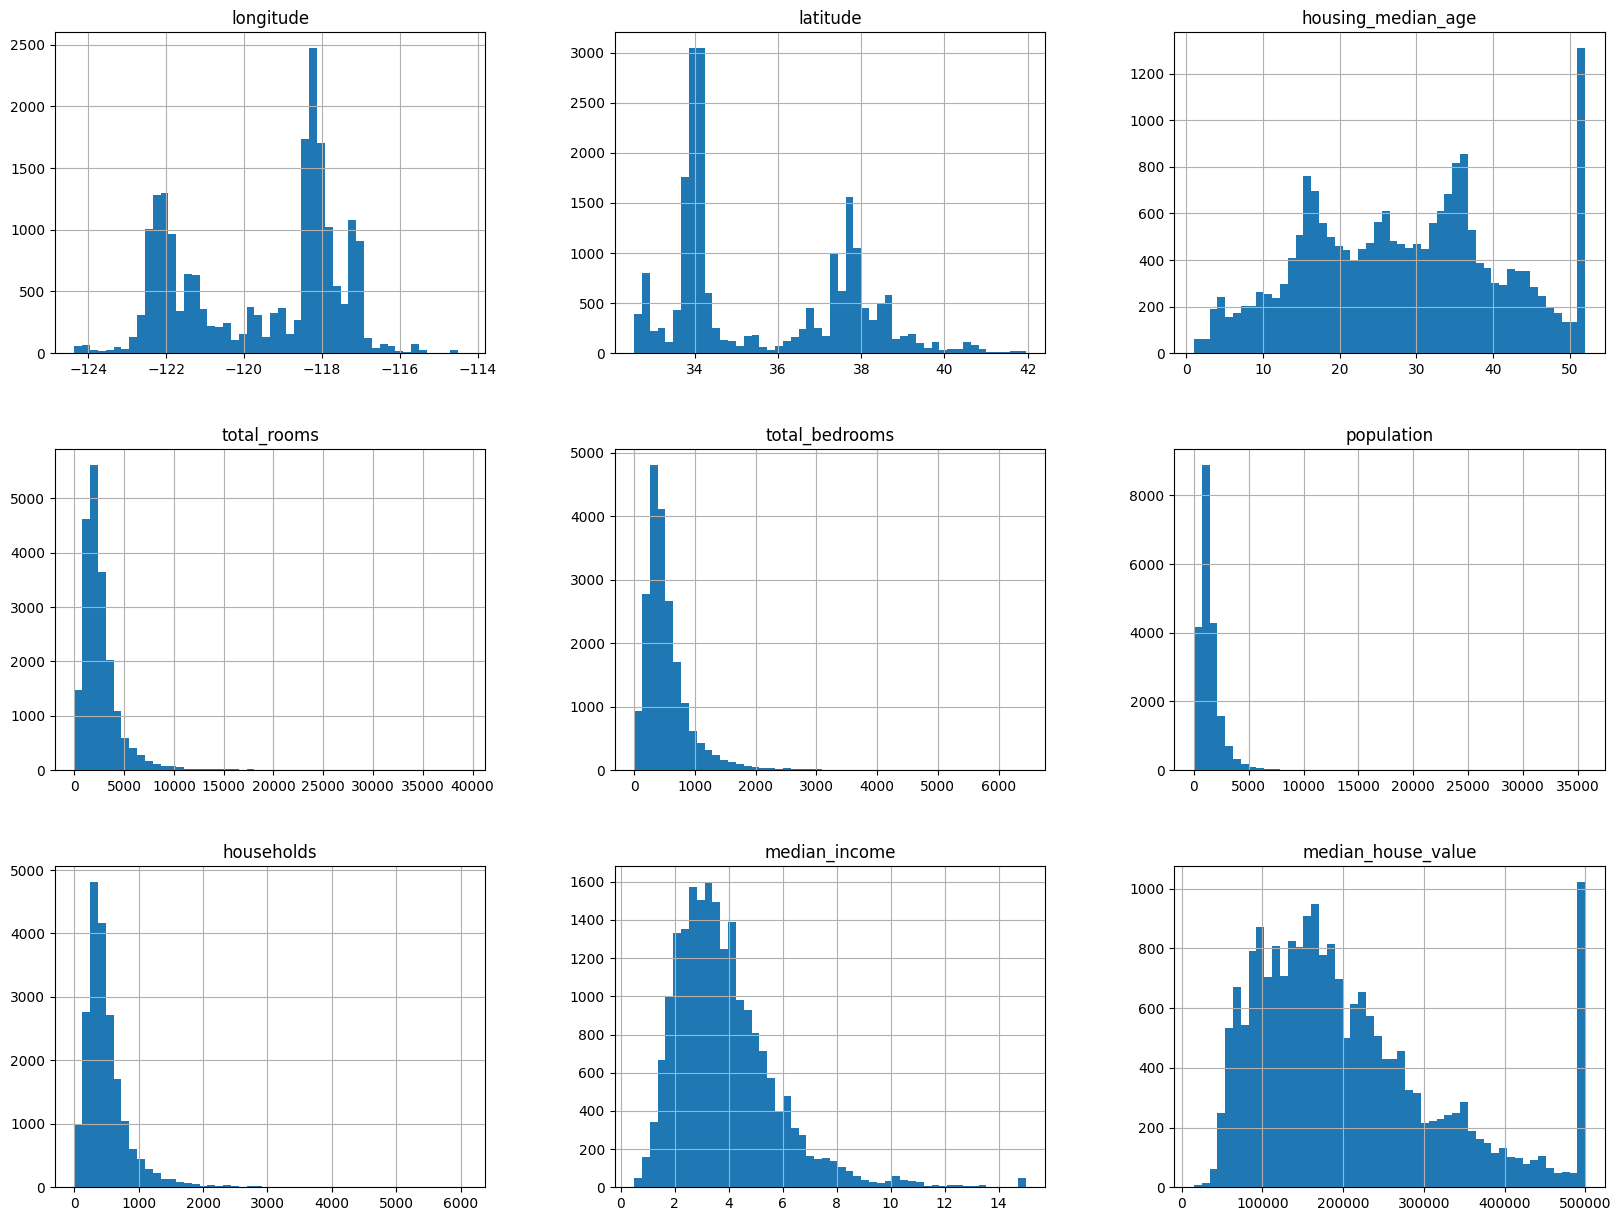

In [7]:
df.hist(bins=50, figsize=(20, 15))
plt.show()

The exploratory data analysis reveals that most numerical attributes, such as population, total_rooms, and households, are heavily right-skewed, indicating a concentration of data points at lower values with a long tail. Notably, the median_house_value and housing_median_age exhibit clear capping at their maximum limits. Furthermore, the geographic data (longitude and latitude) shows distinct clusters, likely representing major metropolitan areas.

<Axes: xlabel='longitude', ylabel='latitude'>

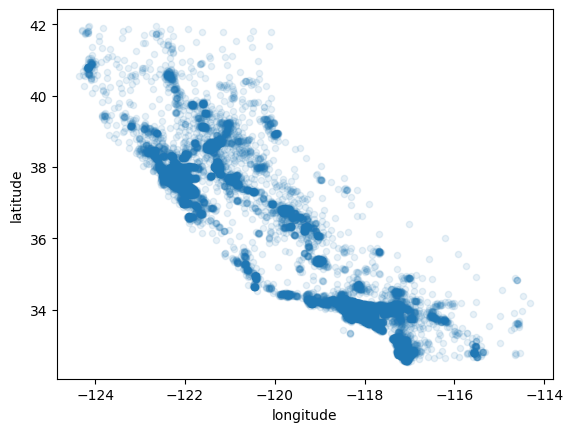

In [8]:
df.plot(kind="scatter", x="longitude", y="latitude",alpha=0.1)

From this graph we can see that the highest density of data is where Los Angeles and San Francisco are. We can also analyze that most of the data is located along the coast and the central part is much less populated. To make the graph more informative, we will add two more features: price and population.

<Axes: xlabel='longitude', ylabel='latitude'>

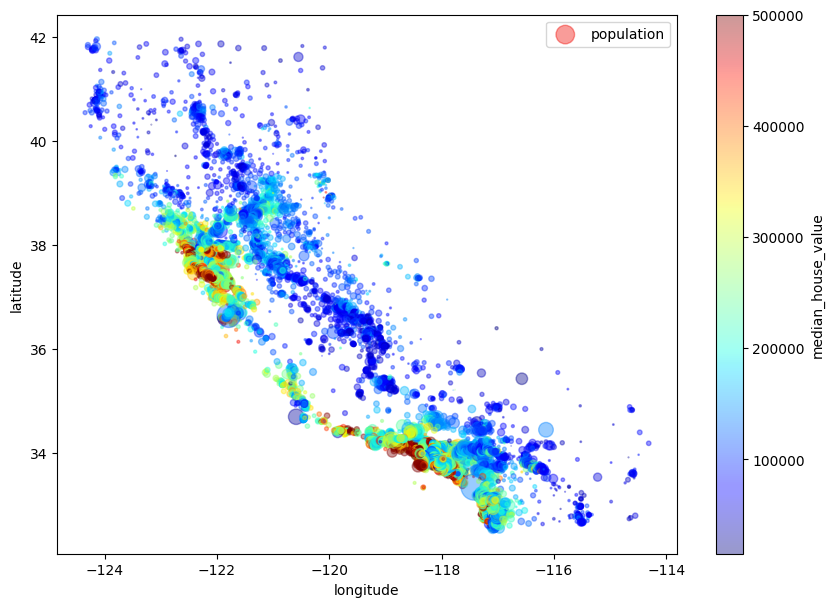

In [9]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4, s=df["population"]/100, label="population", c="median_house_value", cmap="jet", colorbar=True, figsize=(10, 7), sharex=False)

It can be analyzed that the most expensive housing is concentrated along the coastline. Also, the price is strongly correlated with specific neighborhoods and proximity to large cities.

In [10]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64

We see that the most correlated with the cost of the house is salary, which is an important characteristic. We see that the number of rooms has little effect on the cost of housing. This may be because it counts the total number of rooms in the area or it may be some kind of dormitory. Therefore, I will make new characteristics such as the number of rooms in one house, the ratio of bedrooms to common rooms and how many people live in one dwelling because I want to find out how they correlate with the cost. Although the location is negative, according to the Pearson criterion we can say that this is a positive correlation.

Feature engineering

In [11]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

corr_matrix = df.corr(numeric_only=True)

print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.688355
rooms_per_household         0.151344
total_rooms                 0.133294
housing_median_age          0.106432
households                  0.064894
total_bedrooms              0.049686
population_per_household   -0.023639
population                 -0.025300
longitude                  -0.045398
latitude                   -0.144638
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


By creating derived features, we obtained parameters that have a higher correlation coefficient with the target variable. Of particular importance was the feature bedrooms_per_room, which showed a strong negative relationship with price, which will allow the model to more effectively identify different types of properties.

In [12]:
df.drop(['total_bedrooms', 'population', 'population_per_household', 'total_rooms', 'households'], axis=1, inplace=True)

In [13]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

Preprocessing (Column Transformer, Standard Scaler, OneHot Encoding, train_test_split, model selection).

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"].copy()


num_attribs = list(X.drop("ocean_proximity", axis=1).columns)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num",          StandardScaler(),       num_attribs),
    ("cat",          OneHotEncoder(),        cat_attribs),
])

X_prepared = full_pipeline.fit_transform(X)
print(f"The final shape of features: {X_prepared.shape}")


X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.2)


The final shape of features: (20433, 11)


Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lin_reg_model = LinearRegression()

scores = cross_val_score(
    lin_reg_model, 
    X_train, 
    y_train,
    scoring="neg_mean_squared_error",
    cv=10)

rmse_scores = np.sqrt(-scores)

def display_scores(scores, target_variable):
    mean_score = scores.mean()
    std_dev = scores.std()
    avg_price = target_variable.mean()
    relative_error = (mean_score / avg_price) * 100

    print("--- 📊 Model Quality Report (Cross-Validation) ---")
    print(f"Mean Error (RMSE): ${mean_score:,.2f}")
    print(f"Standard Deviation (Stability): ${std_dev:,.2f}")
    print(f"Average House Price: ${avg_price:,.2f}")
    print(f"Relative Error: {relative_error:.2f}%")
    
print("Result of using Linear Regression: ")
display_scores(rmse_scores, y)

Result of using Linear Regression: 
--- 📊 Model Quality Report (Cross-Validation) ---
Mean Error (RMSE): $70,893.19
Standard Deviation (Stability): $2,200.05
Average House Price: $206,864.41
Relative Error: 34.27%


The Cross-Validation results indicate a high bias (underfitting). While the low standard deviation ($2,200) shows that the model is stable and consistent across different data folds, the high RMSE relative to the average price demonstrates a lack of predictive power. This suggests that the features provided do not have a strong linear relationship with the target variable, or the model lacks the complexity needed to model the data.

Decisison Tree

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

housing_predictions = tree_reg.predict(X_train)

tree_mse = mean_squared_error(y_train, housing_predictions)
tree_rmse = np.sqrt(tree_mse)

scores = cross_val_score(
    tree_reg, 
    X_train, 
    y_train,
    scoring="neg_mean_squared_error", 
    cv=10)

tree_rmse_scores = np.sqrt(-scores)

print("Result of using Decision Tree: ")
display_scores(tree_rmse_scores, y)

Result of using Decision Tree: 
--- 📊 Model Quality Report (Cross-Validation) ---
Mean Error (RMSE): $67,563.62
Standard Deviation (Stability): $2,415.08
Average House Price: $206,864.41
Relative Error: 32.66%


The Decision Tree model yields an RMSE of $67,563 with a stability (standard deviation) of $2,415. Although this model is more flexible than Linear Regression, the cross-validation scores reveal that it still performs poorly on unseen data. The similarity in error rates between the two models indicates that we are likely reaching the limits of simple, individual algorithms for this specific dataset.
So I decided to do hyperparameter tuning and check whether it will have an impact on final results.

Tuned Decision tree

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid_tree = [
    {'max_depth': [None, 5, 10, 15], 'min_samples_leaf': [1, 5, 10, 20], 'max_features': [2, 4, 6, 8]}
]

tree_reg = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(tree_reg, param_grid_tree, cv=5, scoring="neg_mean_squared_error", return_train_score=True)

grid_search.fit(X_train, y_train)

print("The best parameters:", grid_search.best_params_)

best_tree_rmse = np.sqrt(-grid_search.best_score_)
print("Result of using Tuned Decision Tree: ")
display_scores(best_tree_rmse, y)

The best parameters: {'max_depth': None, 'max_features': 8, 'min_samples_leaf': 10}
Result of using Tuned Decision Tree: 
--- 📊 Model Quality Report (Cross-Validation) ---
Mean Error (RMSE): $58,257.29
Standard Deviation (Stability): $0.00
Average House Price: $206,864.41
Relative Error: 28.16%


The grid search successfully identified a more robust parameter set that reduced the RMSE by approximately $9,000. Setting min_samples_leaf to 10 acted as a form of regularization, preventing the tree from growing too deep and overfitting individual data points. Note: The 0.00 stability score is a result of calculating the standard deviation on a single 'best score' value rather than across the full cross-validation folds.

Random forest regressor.

In [25]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)

forest_scores = cross_val_score(forest_reg, X_train, y_train, scoring="neg_mean_squared_error", cv=10)

forest_rmse_scores = np.sqrt(-forest_scores)

print("Result of using Random Forest Regressor: ")
display_scores(forest_rmse_scores, y)

Result of using Random Forest Regressor: 
--- 📊 Model Quality Report (Cross-Validation) ---
Mean Error (RMSE): $49,141.71
Standard Deviation (Stability): $1,806.77
Average House Price: $206,864.41
Relative Error: 23.76%


The Random Forest Regressor delivered a significant breakthrough in model performance. By leveraging Ensemble Learning, the Mean Error (RMSE) was reduced to $49,141, bringing the Relative Error down to 23.76%. This confirms that combining multiple decision trees effectively captures complex nonlinear relationships in the data that simpler models failed to recognize. Let`s try doing tuned Random forest regressor.

Tuned Random forest regressor.

In [26]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_features': [4, 6, 8, 12],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]}

forest_reg = RandomForestRegressor(random_state=42)

grid_search = RandomizedSearchCV(forest_reg, param_grid, cv=5, scoring="neg_mean_squared_error", verbose=2, n_jobs=-1, return_train_score=True)

grid_search.fit(X_train, y_train)

print("The best parameters:", grid_search.best_score_)

best_random = np.sqrt(-grid_search.best_score_)
print("Result of using Tuned Random Forest Regressor: ")
display_scores(best_random, y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best parameters: -2409125051.9731627
Result of using Tuned Random Forest Regressor: 
--- 📊 Model Quality Report (Cross-Validation) ---
Mean Error (RMSE): $49,082.84
Standard Deviation (Stability): $0.00
Average House Price: $206,864.41
Relative Error: 23.73%


To push the model's performance to its limit, I performed Hyperparameter Tuning using RandomizedSearchCV. While the improvement in RMSE was marginal compared to the baseline Random Forest, this step was essential to ensure the model is properly regularized and optimized. The minimal change in error indicates that the default ensemble parameters were already very effective for this dataset.

Final test.

In [29]:
final_model = grid_search.best_estimator_
final_predictions = final_model.predict(X_test)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print("--- 🏁 Final Performance on Test Set ---")
print(f"Final RMSE: ${final_rmse:,.2f}")

final_relative_error = (final_rmse / y_test.mean()) * 100

print(f"Relative Error: {final_relative_error:.2f}%")

--- 🏁 Final Performance on Test Set ---
Final RMSE: $47,650.56
Relative Error: 23.05%


The final model evaluation was performed on the X_test and y_test datasets created earlier in the notebook. Since the test features were pre-transformed, they were directly fed into the optimized Random Forest model. The resulting RMSE of $47651 shows how well the model performs on completely new data.

In [30]:
joblib.dump(full_pipeline, "full_pipeline.pkl")
joblib.dump(final_model, "final_model.pkl")

['final_model.pkl']

To transition from research to deployment, I am saving the trained components using joblib. I exported both the preprocessing pipeline and the final optimized model. This ensures that the Streamlit application can apply the same transformations (scaling, encoding) to new user input before generating predictions, maintaining consistency between training and production.